# Manual Projection Previews

## Workflow

Use this notebook when you want to inspect manual panorama previews outside the default OpenCV Stitcher pruning logic. It keeps the experimental flat and cylindrical projections in one place while the main OpenCV notebook stays focused on the built-in stitcher.

In [25]:
from pathlib import Path
import sys
import json
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = False

## Module 1: Paths

Cell này làm 3 việc:
- tìm `PROJECT_ROOT`
- trỏ đến `data/raw`
- đảm bảo folder output cho nhánh `openCV` đã tồn tại

In [26]:
def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), start.resolve().parent]
    for candidate in candidates:
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/raw")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_utils.panorama_dataset import list_scene_dirs, ordered_scene_files

RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_PANORAMA_DIR = PROJECT_ROOT / "outputs" / "openCV" / "panoramas"
OUTPUT_LOG_DIR = PROJECT_ROOT / "outputs" / "openCV" / "logs"

OUTPUT_PANORAMA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_LOG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("OUTPUT_PANORAMA_DIR:", OUTPUT_PANORAMA_DIR)
print("OUTPUT_LOG_DIR:", OUTPUT_LOG_DIR)

PROJECT_ROOT: F:\CV\School\Project
RAW_DIR: F:\CV\School\Project\data\raw
OUTPUT_PANORAMA_DIR: F:\CV\School\Project\outputs\openCV\panoramas
OUTPUT_LOG_DIR: F:\CV\School\Project\outputs\openCV\logs


## Module 2: User Config

In [27]:
SCENE_ID = "scene_28"
STITCHER_MODE = "PANORAMA"
SHOW_INPUT_STRIP = True


## Module 5: Image Utilities

Module này xử lý các thao tác cơ bản trên ảnh:
- resize giữ tỉ lệ
- đổi BGR sang RGB để hiển thị bằng matplotlib
- đo blur / brightness / contrast của từng ảnh

In [28]:
def resize_keep_aspect(image: np.ndarray, max_width: int) -> np.ndarray:
    height, width = image.shape[:2]
    if width <= max_width:
        return image
    scale = max_width / width
    return cv2.resize(
        image,
        (int(round(width * scale)), int(round(height * scale))),
        interpolation=cv2.INTER_AREA,
    )


def bgr_to_rgb(image: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def image_stats(image_bgr: np.ndarray, file_name: str) -> dict:
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    return {
        "file": file_name,
        "width": int(image_bgr.shape[1]),
        "height": int(image_bgr.shape[0]),
        "blur_score": round(float(cv2.Laplacian(gray, cv2.CV_64F).var()), 2),
        "brightness_mean": round(float(gray.mean()), 2),
        "contrast_std": round(float(gray.std()), 2),
    }


## Module 7: Preview Helpers

Cell này hiển thị toàn bộ ảnh đầu vào của một scene theo dạng strip để bạn kiểm tra:
- thứ tự ảnh
- hướng ảnh
- mức overlap bằng mắt

In [29]:
def preview_scene(scene_id: str, max_width: int = 420):
    scene_dir = RAW_DIR / scene_id
    files, reference_files, meta, _ = ordered_scene_files(scene_dir)
    audit_summary = meta.get("audit_summary", {}) or {}
    stability = audit_summary.get("stability_check", {}) or {}

    display(
        pd.DataFrame(
            [
                {
                    "scene_id": scene_id,
                    "num_images": len(files),
                    "num_reference_images": len(reference_files),
                    "capture_group": meta.get("capture_group"),
                    "category": meta.get("category"),
                    "difficulty": meta.get("difficulty"),
                    "stitcher_status": audit_summary.get("stitcher_status"),
                    "ok_rate": stability.get("ok_rate"),
                    "stability_label": stability.get("stability_label"),
                    "output_consistent": stability.get("is_output_consistent"),
                }
            ]
        )
    )

    figure, axes = plt.subplots(1, len(files), figsize=(max(4, 3 * len(files)), 4))
    if len(files) == 1:
        axes = [axes]

    for axis, file_path in zip(axes, files):
        image = cv2.imread(str(file_path))
        image = resize_keep_aspect(image, max_width)
        axis.imshow(bgr_to_rgb(image))
        axis.set_title(file_path.name, fontsize=8)
        axis.axis("off")

    figure.suptitle(scene_id)
    plt.tight_layout()
    plt.show()

    if reference_files:
        print("Reference files excluded from stitch chain:", [path.name for path in reference_files])


,scene_id,num_images,num_reference_images,capture_group,category,difficulty,stitcher_status,ok_rate,stability_label,output_consistent
0,scene_28,6,0,None,None,None,None,None,None,None


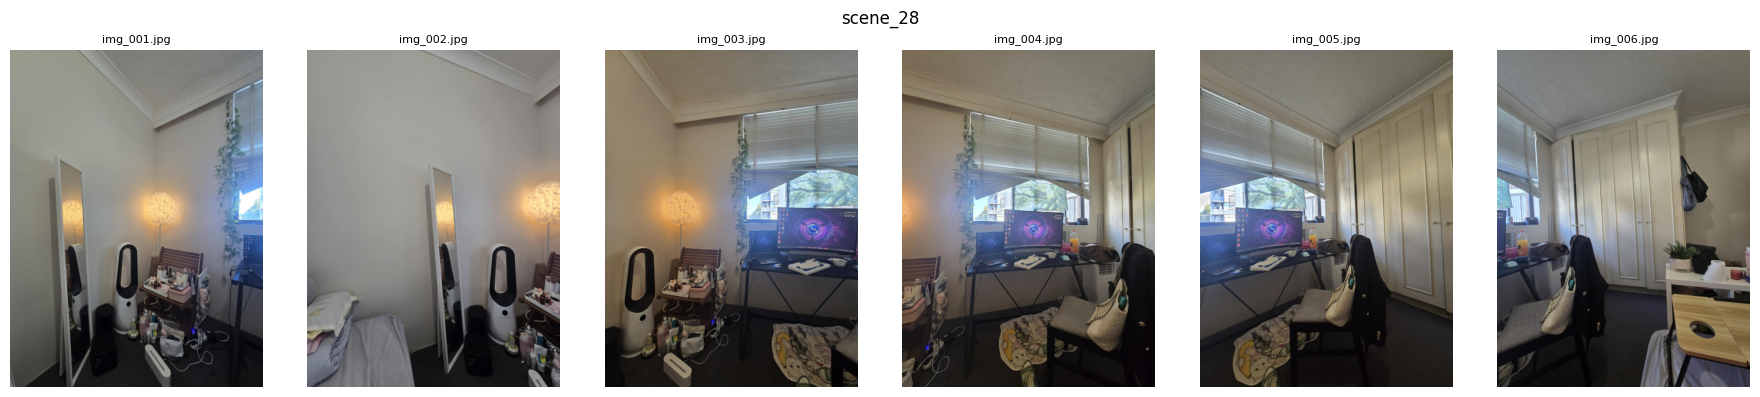

In [30]:
if SHOW_INPUT_STRIP:
    preview_scene(SCENE_ID)
else:
    print("Set SHOW_INPUT_STRIP = True to preview the ordered inputs.")


## Manual Full-Canvas Preview

Phần này mô phỏng một stitcher phẳng tối giản do chúng ta tự ghép bằng tay.

Mục tiêu của preview này không phải là tạo panorama đẹp nhất, mà là để bóc tách hình học:
- ảnh nào nối với ảnh nào
- transform được chuyền dọc chuỗi ra sao
- canvas cuối cùng rộng tới đâu nếu giữ tất cả ảnh
- drift tích lũy sẽ biểu hiện như thế nào khi không để OpenCV tự prune component

Vì thế, full-canvas preview thường hữu ích nhất cho debug hơn là cho kết quả cuối.


### Full-Canvas Part 1: Config And Output Targets

Cell này định nghĩa toàn bộ tham số điều khiển preview phẳng:
- `MANUAL_PREVIEW_MAX_LONG_EDGE`: scale ảnh xuống trước khi match và warp để giữ tốc độ
- `MANUAL_PREVIEW_ANCHOR`: ảnh nào được dùng làm hệ tọa độ gốc của chuỗi
- `MANUAL_PREVIEW_*`: ngưỡng cho ORB/SIFT, ratio test, RANSAC
- `MANUAL_PREVIEW_MAX_ESTIMATED_GB`: hàng rào an toàn để tránh cấp phát canvas quá lớn

Nó cũng chuẩn bị thư mục output cho panorama, overlay và log JSON. Đây là nơi notebook ghi các file debug để bạn xem lại ngoài notebook.


In [31]:
MANUAL_PREVIEW_MAX_LONG_EDGE = 1600
MANUAL_PREVIEW_ANCHOR = None  # 1-based image index, or None to use the middle image
MANUAL_PREVIEW_SAVE_OUTPUTS = True
MANUAL_PREVIEW_RANSAC_THRESH = 4.0
MANUAL_PREVIEW_RATIO_TEST = 0.75
MANUAL_PREVIEW_ORB_FEATURES = 6000
MANUAL_PREVIEW_MAX_ESTIMATED_GB = 4.0

MANUAL_OUTPUT_PANORAMA_DIR = PROJECT_ROOT / "outputs" / "manual" / "panoramas"
MANUAL_OUTPUT_LOG_DIR = PROJECT_ROOT / "outputs" / "manual" / "logs"
MANUAL_OUTPUT_PANORAMA_DIR.mkdir(parents=True, exist_ok=True)
MANUAL_OUTPUT_LOG_DIR.mkdir(parents=True, exist_ok=True)

MANUAL_PALETTE = [
    (235, 99, 71),
    (60, 180, 75),
    (66, 133, 244),
    (255, 193, 7),
    (171, 71, 188),
    (0, 188, 212),
    (255, 112, 67),
    (124, 179, 66),
]


### Full-Canvas Part 2: Preprocessing And Feature Helpers

Những helper này xử lý các thao tác cơ bản trước khi ghép:
- `resize_long_edge`: chuẩn hóa kích thước ảnh theo cạnh dài
- `gray_clahe`: chuyển sang grayscale và tăng tương phản cục bộ để dễ phát hiện keypoint hơn
- `detector_and_norm`: chọn detector và khoảng cách matcher phù hợp với ORB hoặc SIFT
- `classify_manual_pair`: biến kết quả matching thành nhãn `strong / ok / weak / fail`

Điểm quan trọng ở đây là preview manual vẫn dùng OpenCV primitives, nhưng logic quyết định được viết tay. Tức là chúng ta đang tự ráp pipeline chứ không gọi `cv2.Stitcher`.


In [32]:
def resize_long_edge(image: np.ndarray, max_long_edge: int) -> np.ndarray:
    height, width = image.shape[:2]
    long_edge = max(height, width)
    if long_edge <= max_long_edge:
        return image
    scale = max_long_edge / long_edge
    return cv2.resize(
        image,
        (int(round(width * scale)), int(round(height * scale))),
        interpolation=cv2.INTER_AREA,
    )



def gray_clahe(image_bgr: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)



def detector_and_norm(method: str):
    if method == "orb":
        return cv2.ORB_create(nfeatures=MANUAL_PREVIEW_ORB_FEATURES, fastThreshold=10), cv2.NORM_HAMMING
    if method == "sift" and hasattr(cv2, "SIFT_create"):
        return cv2.SIFT_create(nfeatures=4000), cv2.NORM_L2
    return None, None



def classify_manual_pair(good_matches: int, inliers: int, inlier_ratio: float, homography_ok: bool) -> str:
    if not homography_ok or inliers < 8:
        return "fail"
    if inliers >= 40 and inlier_ratio >= 0.45:
        return "strong"
    if inliers >= 18 and inlier_ratio >= 0.25:
        return "ok"
    return "weak"


### Full-Canvas Part 3: Adjacent Pair Estimation

Đây là khối tìm transform giữa hai ảnh kề nhau:
- detect keypoints trên hai ảnh đã CLAHE
- chạy KNN matching + ratio test
- ước lượng homography bằng RANSAC
- đo số inlier và median reprojection error
- chọn ứng viên tốt nhất giữa ORB và SIFT

Tại bước này, preview chỉ giải bài toán cục bộ giữa `image_a` và `image_b`. Nó chưa hiểu toàn chuỗi, chưa tối ưu global camera, và chưa biết scene nào nên bị loại bỏ.


In [33]:
def estimate_adjacent_homography(image_a_bgr: np.ndarray, image_b_bgr: np.ndarray, image_a_name: str, image_b_name: str):
    gray_a = gray_clahe(image_a_bgr)
    gray_b = gray_clahe(image_b_bgr)
    candidates = []

    for method in ["orb", "sift"]:
        detector, norm = detector_and_norm(method)
        if detector is None:
            continue

        keypoints_a, descriptors_a = detector.detectAndCompute(gray_a, None)
        keypoints_b, descriptors_b = detector.detectAndCompute(gray_b, None)
        keypoints_a = keypoints_a or []
        keypoints_b = keypoints_b or []

        record = {
            "image_a": image_a_name,
            "image_b": image_b_name,
            "method": f"{method}_clahe",
            "raw_matches": 0,
            "good_matches": 0,
            "inliers": 0,
            "inlier_ratio": 0.0,
            "homography_ok": False,
            "pair_label": "fail",
            "median_reproj_error": None,
        }

        if (
            descriptors_a is None
            or descriptors_b is None
            or len(keypoints_a) < 8
            or len(keypoints_b) < 8
        ):
            candidates.append((None, record))
            continue

        matcher = cv2.BFMatcher(norm)
        raw_matches = matcher.knnMatch(descriptors_b, descriptors_a, k=2)
        good_matches = []
        for pair in raw_matches:
            if len(pair) < 2:
                continue
            first, second = pair
            if first.distance < MANUAL_PREVIEW_RATIO_TEST * second.distance:
                good_matches.append(first)

        record["raw_matches"] = int(len(raw_matches))
        record["good_matches"] = int(len(good_matches))

        homography = None
        mask = None
        if len(good_matches) >= 8:
            src = np.float32([keypoints_b[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst = np.float32([keypoints_a[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            homography, mask = cv2.findHomography(src, dst, cv2.RANSAC, MANUAL_PREVIEW_RANSAC_THRESH)

        if mask is not None:
            inliers = int(mask.ravel().sum())
            record["inliers"] = inliers
            record["inlier_ratio"] = round(float(inliers / max(len(good_matches), 1)), 3)
            record["homography_ok"] = bool(homography is not None and inliers >= 8)

            if homography is not None and inliers > 0:
                projected = cv2.perspectiveTransform(src, homography)
                errors = np.linalg.norm((projected - dst).reshape(-1, 2), axis=1)
                inlier_errors = errors[mask.ravel().astype(bool)]
                if len(inlier_errors) > 0:
                    record["median_reproj_error"] = round(float(np.median(inlier_errors)), 3)

        record["pair_label"] = classify_manual_pair(
            record["good_matches"],
            record["inliers"],
            record["inlier_ratio"],
            record["homography_ok"],
        )
        candidates.append((homography, record))

    if not candidates:
        raise ValueError(f"No matcher available for {image_a_name} -> {image_b_name}")

    best_homography, best_record = max(
        candidates,
        key=lambda item: (
            item[1]["homography_ok"],
            item[1]["inliers"],
            item[1]["good_matches"],
            item[1]["method"] == "sift_clahe",
        ),
    )
    return best_homography, best_record


### Full-Canvas Part 4: Chain Composition, Canvas Build, And Visualization

`manual_full_canvas_preview()` là phần nối tất cả mảnh lại với nhau:
1. đọc toàn bộ ảnh của scene theo thứ tự đã chốt
2. ước lượng homography cho từng cặp kề nhau
3. chọn một ảnh anchor ở giữa chuỗi
4. nhân dồn transform để đưa mọi ảnh về hệ tọa độ anchor
5. chiếu tất cả corners để ước lượng canvas
6. dùng memory guard để bỏ qua những canvas quá lớn
7. warp từng ảnh lên canvas chung
8. cộng dồn / average các pixel chồng lắp
9. tạo footprint overlay, coverage heatmap, và log JSON

Đây là phần quan trọng nhất để hiểu vì sao preview manual có thể kém hơn OpenCV:
- transform bị cộng dồn nên drift dễ tăng
- blending chỉ là average đơn giản
- không có bước camera adjustment toàn cục như OpenCV Stitcher
- không có seam finder hay component pruning thông minh


In [34]:
def manual_full_canvas_preview(
    scene_id: str,
    max_long_edge: int = 1600,
    anchor_1based: int | None = None,
    save_outputs: bool = True,
):
    scene_dir = RAW_DIR / scene_id
    if not scene_dir.exists():
        raise FileNotFoundError(f"Scene not found: {scene_dir}")

    files, reference_files, meta, used_meta_order = ordered_scene_files(scene_dir)
    if len(files) < 2:
        raise ValueError(f"Scene {scene_id} must have at least 2 images")

    images = []
    for path in files:
        image = cv2.imread(str(path))
        if image is None:
            raise ValueError(f"Could not read image: {path}")
        images.append(resize_long_edge(image, max_long_edge))

    pair_records = []
    homographies_next_to_prev = []
    for index in range(len(images) - 1):
        homography, record = estimate_adjacent_homography(
            images[index],
            images[index + 1],
            files[index].name,
            files[index + 1].name,
        )
        record["pair_index"] = index + 1
        pair_records.append(record)
        homographies_next_to_prev.append(homography)

    failed_pairs = [record for homography, record in zip(homographies_next_to_prev, pair_records) if homography is None]
    if failed_pairs:
        failed_names = [f"{record['image_a']} -> {record['image_b']}" for record in failed_pairs]
        raise ValueError("Manual full-canvas preview could not bridge the whole chain: " + ", ".join(failed_names))

    if anchor_1based is None:
        anchor_index = len(images) // 2
    else:
        anchor_index = int(anchor_1based) - 1
    if anchor_index < 0 or anchor_index >= len(images):
        raise ValueError(f"Anchor index out of range: {anchor_1based}")

    transforms_to_anchor = [None] * len(images)
    transforms_to_anchor[anchor_index] = np.eye(3, dtype=np.float64)

    for index in range(anchor_index + 1, len(images)):
        transforms_to_anchor[index] = transforms_to_anchor[index - 1] @ homographies_next_to_prev[index - 1]

    for index in range(anchor_index - 1, -1, -1):
        try:
            inverse_h = np.linalg.inv(homographies_next_to_prev[index])
        except np.linalg.LinAlgError as exc:
            raise ValueError(
                f"Could not invert pair transform for {files[index].name} -> {files[index + 1].name}"
            ) from exc
        transforms_to_anchor[index] = transforms_to_anchor[index + 1] @ inverse_h

    projected_all = []
    image_footprints = []
    for path, image, transform in zip(files, images, transforms_to_anchor):
        height, width = image.shape[:2]
        corners = np.float32([[0, 0], [width, 0], [width, height], [0, height]]).reshape(-1, 1, 2)
        projected = cv2.perspectiveTransform(corners, transform).reshape(-1, 2)
        projected_all.append(projected)
        image_footprints.append(
            {
                "file": path.name,
                "width": int(width),
                "height": int(height),
                "projected_corners_anchor": [[round(float(x), 1), round(float(y), 1)] for x, y in projected],
            }
        )

    all_points = np.vstack(projected_all)
    min_xy = np.floor(all_points.min(axis=0))
    max_xy = np.ceil(all_points.max(axis=0))
    translate = np.array(
        [
            [1.0, 0.0, -float(min_xy[0])],
            [0.0, 1.0, -float(min_xy[1])],
            [0.0, 0.0, 1.0],
        ],
        dtype=np.float64,
    )

    canvas_width = int(max(1, np.ceil(max_xy[0] - min_xy[0])))
    canvas_height = int(max(1, np.ceil(max_xy[1] - min_xy[1])))

    estimated_alloc_bytes = canvas_width * canvas_height * (3 * 4 + 1 * 4 + 2)
    estimated_alloc_gb = estimated_alloc_bytes / (1024 ** 3)
    if estimated_alloc_gb > MANUAL_PREVIEW_MAX_ESTIMATED_GB:
        manual_log_path = MANUAL_OUTPUT_LOG_DIR / f"{scene_id}_manual_full_canvas_preview.json"
        summary = {
            "scene_id": scene_id,
            "scene_dir": str(scene_dir),
            "status": "skipped_large_canvas",
            "reason": "estimated_memory_guard",
            "estimated_alloc_gb": round(float(estimated_alloc_gb), 2),
            "num_images": len(files),
            "num_reference_images": len(reference_files),
            "reference_files": [path.name for path in reference_files],
            "ordered_files": [path.name for path in files],
            "used_meta_order": used_meta_order,
            "anchor_index_1based": int(anchor_index + 1),
            "anchor_file": files[anchor_index].name,
            "max_long_edge": int(max_long_edge),
            "canvas_shape": {"width": int(canvas_width), "height": int(canvas_height)},
            "manual_panorama_path": None,
            "manual_overlay_path": None,
            "manual_coverage_path": None,
            "pair_records": pair_records,
            "image_footprints": image_footprints,
            "generated_at": datetime.now().isoformat(timespec="seconds"),
            "manual_log_path": str(manual_log_path),
        }
        if save_outputs:
            manual_log_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
        display(Markdown(f"### {scene_id} | manual full-canvas preview skipped"))
        display(pd.DataFrame([
            {
                "scene_id": scene_id,
                "status": summary["status"],
                "canvas_shape": summary["canvas_shape"],
                "estimated_alloc_gb": summary["estimated_alloc_gb"],
                "max_long_edge": max_long_edge,
                "manual_log_path": summary["manual_log_path"],
            }
        ]))
        return summary

    accum = np.zeros((canvas_height, canvas_width, 3), dtype=np.float32)
    weight = np.zeros((canvas_height, canvas_width, 1), dtype=np.float32)
    coverage = np.zeros((canvas_height, canvas_width), dtype=np.uint16)

    for record, path, image, transform in zip(image_footprints, files, images, transforms_to_anchor):
        warp_transform = translate @ transform
        warped_image = cv2.warpPerspective(image, warp_transform, (canvas_width, canvas_height))
        warped_mask = cv2.warpPerspective(
            np.full(image.shape[:2], 255, dtype=np.uint8),
            warp_transform,
            (canvas_width, canvas_height),
        )
        valid = (warped_mask > 0).astype(np.float32)
        accum += warped_image.astype(np.float32) * valid[..., None]
        weight += valid[..., None]
        coverage += valid.astype(np.uint16)

        corners = np.float32([[0, 0], [image.shape[1], 0], [image.shape[1], image.shape[0]], [0, image.shape[0]]]).reshape(-1, 1, 2)
        translated_corners = cv2.perspectiveTransform(corners, warp_transform).reshape(-1, 2)
        record["projected_corners_canvas"] = [[round(float(x), 1), round(float(y), 1)] for x, y in translated_corners]
        record["coverage_pixels"] = int(valid.sum())

    manual_panorama = np.clip(accum / np.clip(weight, 1.0, None), 0, 255).astype(np.uint8)

    coverage_max = int(coverage.max()) if coverage.size else 0
    coverage_norm = np.zeros_like(coverage, dtype=np.uint8)
    if coverage_max > 0:
        coverage_norm = np.clip((coverage.astype(np.float32) / coverage_max) * 255.0, 0, 255).astype(np.uint8)
    coverage_heatmap = cv2.applyColorMap(coverage_norm, cv2.COLORMAP_TURBO)
    coverage_heatmap[coverage == 0] = 0

    color_layer = np.zeros_like(manual_panorama)
    footprint_overlay = manual_panorama.copy()
    for index, record in enumerate(image_footprints):
        polygon = np.round(np.array(record["projected_corners_canvas"], dtype=np.float32)).astype(np.int32)
        color = MANUAL_PALETTE[index % len(MANUAL_PALETTE)]
        cv2.fillPoly(color_layer, [polygon], color)
    footprint_overlay = cv2.addWeighted(manual_panorama, 1.0, color_layer, 0.18, 0.0)

    for index, record in enumerate(image_footprints):
        polygon = np.round(np.array(record["projected_corners_canvas"], dtype=np.float32)).astype(np.int32)
        color = MANUAL_PALETTE[index % len(MANUAL_PALETTE)]
        cv2.polylines(footprint_overlay, [polygon], isClosed=True, color=color, thickness=3)
        label_x = int(np.mean(polygon[:, 0]))
        label_y = int(np.mean(polygon[:, 1]))
        label = f"{index + 1}:{record['file']}"
        cv2.putText(footprint_overlay, label, (label_x, label_y), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 3, cv2.LINE_AA)
        cv2.putText(footprint_overlay, label, (label_x, label_y), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 1, cv2.LINE_AA)

    opencv_panorama_path = OUTPUT_PANORAMA_DIR / f"{scene_id}_opencv_{STITCHER_MODE.lower()}.jpg"
    opencv_panorama = cv2.imread(str(opencv_panorama_path)) if opencv_panorama_path.exists() else None
    opencv_shape = None if opencv_panorama is None else {
        "width": int(opencv_panorama.shape[1]),
        "height": int(opencv_panorama.shape[0]),
    }

    manual_panorama_path = None
    manual_overlay_path = None
    manual_coverage_path = None
    manual_log_path = MANUAL_OUTPUT_LOG_DIR / f"{scene_id}_manual_full_canvas_preview.json"
    if save_outputs:
        manual_panorama_path = MANUAL_OUTPUT_PANORAMA_DIR / f"{scene_id}_manual_full_canvas_preview.jpg"
        manual_overlay_path = MANUAL_OUTPUT_PANORAMA_DIR / f"{scene_id}_manual_full_canvas_overlay.jpg"
        manual_coverage_path = MANUAL_OUTPUT_PANORAMA_DIR / f"{scene_id}_manual_full_canvas_coverage.jpg"
        cv2.imwrite(str(manual_panorama_path), manual_panorama)
        cv2.imwrite(str(manual_overlay_path), footprint_overlay)
        cv2.imwrite(str(manual_coverage_path), coverage_heatmap)

    summary = {
        "scene_id": scene_id,
        "scene_dir": str(scene_dir),
        "num_images": len(files),
        "num_reference_images": len(reference_files),
        "reference_files": [path.name for path in reference_files],
        "ordered_files": [path.name for path in files],
        "used_meta_order": used_meta_order,
        "anchor_index_1based": int(anchor_index + 1),
        "anchor_file": files[anchor_index].name,
        "max_long_edge": int(max_long_edge),
        "canvas_shape": {"width": int(canvas_width), "height": int(canvas_height)},
        "opencv_panorama_shape": opencv_shape,
        "manual_panorama_path": None if manual_panorama_path is None else str(manual_panorama_path),
        "manual_overlay_path": None if manual_overlay_path is None else str(manual_overlay_path),
        "manual_coverage_path": None if manual_coverage_path is None else str(manual_coverage_path),
        "opencv_panorama_path": None if opencv_panorama is None else str(opencv_panorama_path),
        "pair_records": pair_records,
        "image_footprints": image_footprints,
        "generated_at": datetime.now().isoformat(timespec="seconds"),
    }

    if save_outputs:
        manual_log_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

    display(Markdown(f"### {scene_id} | manual full-canvas preview"))
    display(pd.DataFrame([
        {
            "scene_id": scene_id,
            "num_images": len(files),
            "anchor_file": files[anchor_index].name,
            "canvas_shape": summary["canvas_shape"],
            "opencv_panorama_shape": opencv_shape,
            "manual_panorama_path": summary["manual_panorama_path"],
            "manual_log_path": str(manual_log_path),
        }
    ]))
    display(pd.DataFrame(pair_records)[[
        "pair_index",
        "image_a",
        "image_b",
        "method",
        "good_matches",
        "inliers",
        "inlier_ratio",
        "pair_label",
        "median_reproj_error",
    ]])

    figure_cols = 4 if opencv_panorama is not None else 3
    fig, axes = plt.subplots(1, figure_cols, figsize=(6 * figure_cols, 6))
    if figure_cols == 1:
        axes = [axes]
    axes = np.atleast_1d(axes)

    axes[0].imshow(bgr_to_rgb(manual_panorama))
    axes[0].set_title("Manual full canvas")
    axes[0].axis("off")

    axes[1].imshow(bgr_to_rgb(footprint_overlay))
    axes[1].set_title("Footprint overlay")
    axes[1].axis("off")

    axes[2].imshow(bgr_to_rgb(coverage_heatmap))
    axes[2].set_title("Coverage heatmap")
    axes[2].axis("off")

    if opencv_panorama is not None:
        axes[3].imshow(bgr_to_rgb(opencv_panorama))
        axes[3].set_title("OpenCV stitcher")
        axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    if reference_files:
        print("Reference files excluded from manual chain:", [path.name for path in reference_files])

    summary["manual_log_path"] = str(manual_log_path)
    return summary


### Full-Canvas Part 5: Execute The Preview

Cell cuối cùng chạy preview phẳng với `SCENE_ID` hiện tại.

Notebook giữ `try/except` ở đây để một scene lỗi không làm hỏng toàn bộ notebook. Nếu fail, bạn vẫn nhận được một record lỗi thay vì notebook dừng hẳn.


### scene_28 | manual full-canvas preview

,scene_id,num_images,anchor_file,canvas_shape,opencv_panorama_shape,manual_panorama_path,manual_log_path
0,scene_28,6,img_004.jpg,"{'width': 8567, 'height': 7212}",None,F:\CV\School\Project\outputs\manual\panoramas\...,F:\CV\School\Project\outputs\manual\logs\scene...


,pair_index,image_a,image_b,method,good_matches,inliers,inlier_ratio,pair_label,median_reproj_error
0,1,img_001.jpg,img_002.jpg,sift_clahe,337,278,0.825,strong,0.746
1,2,img_002.jpg,img_003.jpg,sift_clahe,131,75,0.573,strong,0.851
2,3,img_003.jpg,img_004.jpg,sift_clahe,959,799,0.833,strong,0.920
3,4,img_004.jpg,img_005.jpg,orb_clahe,1366,1109,0.812,strong,1.220
4,5,img_005.jpg,img_006.jpg,orb_clahe,692,606,0.876,strong,1.473


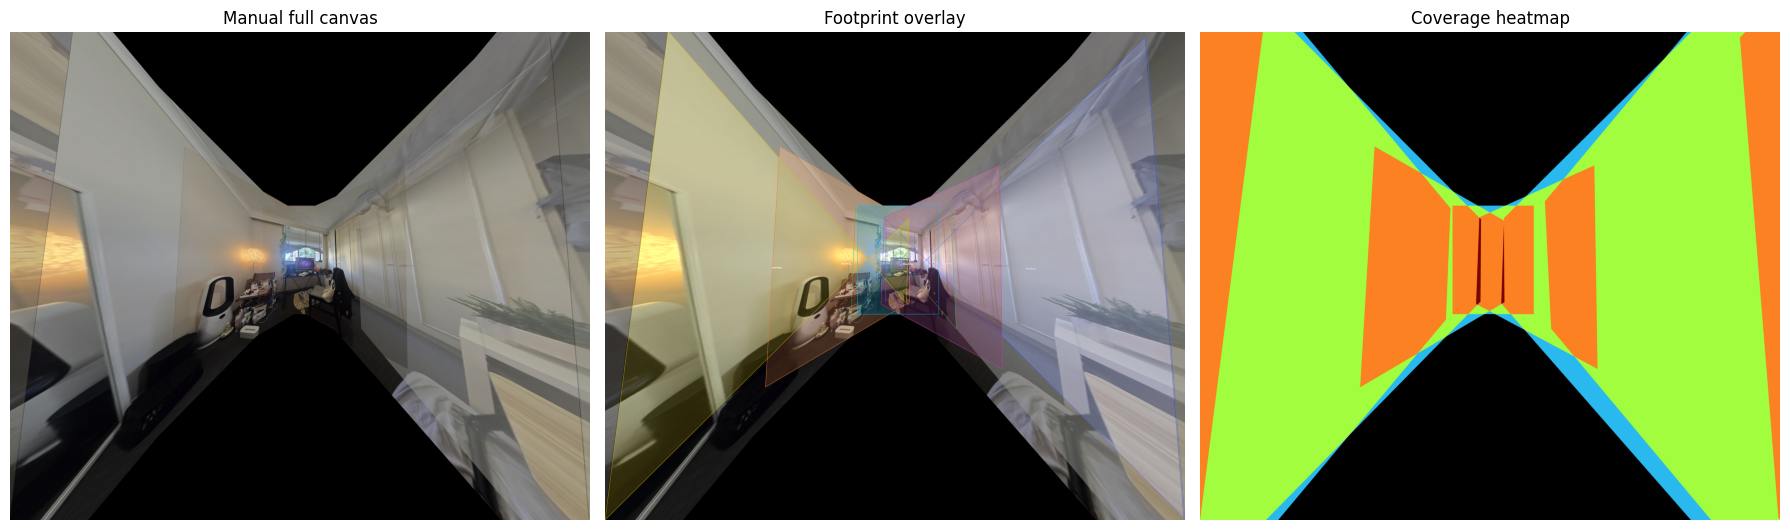

In [35]:
try:
    manual_preview_result = manual_full_canvas_preview(
        scene_id=SCENE_ID,
        max_long_edge=MANUAL_PREVIEW_MAX_LONG_EDGE,
        anchor_1based=MANUAL_PREVIEW_ANCHOR,
        save_outputs=MANUAL_PREVIEW_SAVE_OUTPUTS,
    )
except Exception as exc:
    manual_preview_result = {
        "scene_id": SCENE_ID,
        "status": "error",
        "error_type": type(exc).__name__,
        "error_message": str(exc),
    }
    display(Markdown(f"### {SCENE_ID} | manual full-canvas preview failed"))
    display(pd.DataFrame([manual_preview_result]))


## Manual Cylindrical Preview

Preview này phù hợp hơn với các scene quét rộng quanh người.

Ý tưởng là:
- trước hết bẻ mỗi ảnh sang mặt trụ
- rồi mới ước lượng transform giữa các ảnh kề nhau trong không gian cylindrical
- sau đó ghép tất cả lên một canvas chung

Nó vẫn là một pipeline thủ công, nhưng projection model hợp với wide panorama hơn full-canvas phẳng.


### Cylindrical Part 1: Config

Nhóm tham số này kiểm soát preview cylindrical:
- `CYL_PREVIEW_MAX_LONG_EDGE`: scale ảnh
- `CYL_PREVIEW_FOCAL_SCALE` hoặc `CYL_PREVIEW_FOCAL_PX_OVERRIDE`: giả định focal length cho phép warp cylindrical
- `CYL_PREVIEW_ANCHOR`: anchor ảnh ở giữa hoặc ảnh bạn chọn
- `CYL_PREVIEW_*`: ngưỡng matcher / RANSAC cho không gian cylindrical

Trong preview này, focal length là một giả định gần đúng. Vì vậy kết quả rất hữu ích để debug coverage, nhưng chưa phải calibration chính xác như một panorama engine hoàn chỉnh.


In [36]:
CYL_PREVIEW_MAX_LONG_EDGE = 1600
CYL_PREVIEW_FOCAL_SCALE = 1.15  # focal_px = image_width * scale if focal_px_override is None
CYL_PREVIEW_FOCAL_PX_OVERRIDE = None
CYL_PREVIEW_ANCHOR = None  # 1-based image index, or None to use the middle image
CYL_PREVIEW_SAVE_OUTPUTS = True
CYL_PREVIEW_RANSAC_THRESH = 4.0
CYL_PREVIEW_RATIO_TEST = 0.75
CYL_PREVIEW_ORB_FEATURES = 6000


### Cylindrical Part 2: Warp And Local Geometry Helpers

Khối helper này làm bốn việc:
- resize ảnh đầu vào
- tăng tương phản bằng CLAHE
- warp ảnh và mask sang cylindrical surface
- định nghĩa detector / matcher / rule gán nhãn pair

Khác với preview phẳng, ở đây transform cục bộ không còn là homography đầy đủ mà được ràng vào mô hình đơn giản hơn sau khi đã warp cylindrical.


In [37]:
def cyl_resize_long_edge(image: np.ndarray, max_long_edge: int) -> np.ndarray:
    height, width = image.shape[:2]
    long_edge = max(height, width)
    if long_edge <= max_long_edge:
        return image
    scale = max_long_edge / long_edge
    return cv2.resize(
        image,
        (int(round(width * scale)), int(round(height * scale))),
        interpolation=cv2.INTER_AREA,
    )



def cyl_gray_clahe(image_bgr: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)



def cylindrical_warp(image_bgr: np.ndarray, focal_px: float):
    height, width = image_bgr.shape[:2]
    cx = width / 2.0
    cy = height / 2.0

    y_coords, x_coords = np.indices((height, width), dtype=np.float32)
    theta = (x_coords - cx) / focal_px
    h = (y_coords - cy) / focal_px

    map_x = focal_px * np.tan(theta) + cx
    map_y = focal_px * h / np.cos(theta) + cy

    warped = cv2.remap(
        image_bgr,
        map_x.astype(np.float32),
        map_y.astype(np.float32),
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0),
    )
    mask = cv2.remap(
        np.full((height, width), 255, dtype=np.uint8),
        map_x.astype(np.float32),
        map_y.astype(np.float32),
        interpolation=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )
    return warped, mask



def cyl_detector_and_norm(method: str):
    if method == "orb":
        return cv2.ORB_create(nfeatures=CYL_PREVIEW_ORB_FEATURES, fastThreshold=10), cv2.NORM_HAMMING
    if method == "sift" and hasattr(cv2, "SIFT_create"):
        return cv2.SIFT_create(nfeatures=4000), cv2.NORM_L2
    return None, None



def classify_cyl_pair(good_matches: int, inliers: int, inlier_ratio: float, transform_ok: bool) -> str:
    if not transform_ok or inliers < 8:
        return "fail"
    if inliers >= 40 and inlier_ratio >= 0.45:
        return "strong"
    if inliers >= 18 and inlier_ratio >= 0.25:
        return "ok"
    return "weak"



def affine_2x3_to_3x3(matrix_2x3: np.ndarray) -> np.ndarray:
    return np.vstack([matrix_2x3, np.array([0.0, 0.0, 1.0], dtype=np.float64)])


### Cylindrical Part 3: Pair Transform Estimation In Cylindrical Space

`estimate_cylindrical_pair_transform()` match hai ảnh đã warp cylindrical rồi fit `estimateAffinePartial2D`.

Lý do chọn affine partial ở đây:
- sau khi lên mặt trụ, chuyển động giữa hai ảnh kề nhau thường gần với tịnh tiến + xoay + scale nhẹ hơn
- affine partial thường ổn định hơn homography đầy đủ cho wide sweep debug

Cell này vẫn lưu lại số match, số inlier, reprojection error và cả `dx / dy` để bạn nhìn hướng dịch chuyển của từng cặp.


In [38]:
def estimate_cylindrical_pair_transform(image_a_bgr: np.ndarray, image_b_bgr: np.ndarray, image_a_name: str, image_b_name: str):
    gray_a = cyl_gray_clahe(image_a_bgr)
    gray_b = cyl_gray_clahe(image_b_bgr)
    candidates = []

    for method in ["orb", "sift"]:
        detector, norm = cyl_detector_and_norm(method)
        if detector is None:
            continue

        keypoints_a, descriptors_a = detector.detectAndCompute(gray_a, None)
        keypoints_b, descriptors_b = detector.detectAndCompute(gray_b, None)
        keypoints_a = keypoints_a or []
        keypoints_b = keypoints_b or []

        record = {
            "image_a": image_a_name,
            "image_b": image_b_name,
            "method": f"{method}_clahe_affine",
            "raw_matches": 0,
            "good_matches": 0,
            "inliers": 0,
            "inlier_ratio": 0.0,
            "transform_ok": False,
            "pair_label": "fail",
            "median_reproj_error": None,
            "dx": None,
            "dy": None,
        }

        if (
            descriptors_a is None
            or descriptors_b is None
            or len(keypoints_a) < 8
            or len(keypoints_b) < 8
        ):
            candidates.append((None, record))
            continue

        matcher = cv2.BFMatcher(norm)
        raw_matches = matcher.knnMatch(descriptors_b, descriptors_a, k=2)
        good_matches = []
        for pair in raw_matches:
            if len(pair) < 2:
                continue
            first, second = pair
            if first.distance < CYL_PREVIEW_RATIO_TEST * second.distance:
                good_matches.append(first)

        record["raw_matches"] = int(len(raw_matches))
        record["good_matches"] = int(len(good_matches))

        transform = None
        inlier_mask = None
        if len(good_matches) >= 8:
            src = np.float32([keypoints_b[m.queryIdx].pt for m in good_matches]).reshape(-1, 2)
            dst = np.float32([keypoints_a[m.trainIdx].pt for m in good_matches]).reshape(-1, 2)
            affine, inlier_mask = cv2.estimateAffinePartial2D(
                src,
                dst,
                method=cv2.RANSAC,
                ransacReprojThreshold=CYL_PREVIEW_RANSAC_THRESH,
                maxIters=3000,
                confidence=0.99,
            )
            if affine is not None:
                transform = affine_2x3_to_3x3(affine)

        if inlier_mask is not None:
            inliers = int(inlier_mask.ravel().sum())
            record["inliers"] = inliers
            record["inlier_ratio"] = round(float(inliers / max(len(good_matches), 1)), 3)
            record["transform_ok"] = bool(transform is not None and inliers >= 8)

            if transform is not None and inliers > 0:
                src = np.float32([keypoints_b[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
                dst = np.float32([keypoints_a[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
                projected = cv2.perspectiveTransform(src, transform)
                errors = np.linalg.norm((projected - dst).reshape(-1, 2), axis=1)
                keep = inlier_mask.ravel().astype(bool)
                if keep.any():
                    record["median_reproj_error"] = round(float(np.median(errors[keep])), 3)
                    deltas = (dst - src).reshape(-1, 2)[keep]
                    record["dx"] = round(float(np.median(deltas[:, 0])), 2)
                    record["dy"] = round(float(np.median(deltas[:, 1])), 2)

        record["pair_label"] = classify_cyl_pair(
            record["good_matches"],
            record["inliers"],
            record["inlier_ratio"],
            record["transform_ok"],
        )
        candidates.append((transform, record))

    if not candidates:
        raise ValueError(f"No matcher available for {image_a_name} -> {image_b_name}")

    best_transform, best_record = max(
        candidates,
        key=lambda item: (
            item[1]["transform_ok"],
            item[1]["inliers"],
            item[1]["good_matches"],
            item[1]["method"].startswith("sift"),
        ),
    )
    return best_transform, best_record


### Cylindrical Part 4: Chain Composition, Canvas Build, And Output

`manual_cylindrical_preview()` là nơi toàn bộ chuỗi cylindrical được ghép lại:
1. đọc ảnh theo thứ tự scene
2. resize và warp từng ảnh sang cylindrical surface
3. ước lượng transform giữa các ảnh kề nhau trong cylindrical space
4. chọn anchor và nhân dồn transform
5. tìm canvas đủ lớn để chứa toàn bộ footprint
6. warp các ảnh cylindrical lên canvas
7. average vùng overlap, tạo heatmap và footprint overlay
8. so sánh trực tiếp với panorama OpenCV nếu file đó đã tồn tại

Preview này thường hợp lý hơn full-canvas khi scene quét rộng, nhưng nó vẫn không có global camera optimization hay seam optimization như OpenCV Stitcher.


In [39]:
def manual_cylindrical_preview(
    scene_id: str,
    max_long_edge: int = 1600,
    focal_scale: float = 1.15,
    focal_px_override: float | None = None,
    anchor_1based: int | None = None,
    save_outputs: bool = True,
):
    scene_dir = RAW_DIR / scene_id
    if not scene_dir.exists():
        raise FileNotFoundError(f"Scene not found: {scene_dir}")

    files, reference_files, meta, used_meta_order = ordered_scene_files(scene_dir)
    if len(files) < 2:
        raise ValueError(f"Scene {scene_id} must have at least 2 images")

    resized_images = []
    cylindrical_images = []
    cylindrical_masks = []
    image_records = []
    focal_lengths = []

    for path in files:
        image = cv2.imread(str(path))
        if image is None:
            raise ValueError(f"Could not read image: {path}")
        image = cyl_resize_long_edge(image, max_long_edge)
        focal_px = float(focal_px_override) if focal_px_override is not None else float(image.shape[1] * focal_scale)
        cyl_image, cyl_mask = cylindrical_warp(image, focal_px)
        resized_images.append(image)
        cylindrical_images.append(cyl_image)
        cylindrical_masks.append(cyl_mask)
        focal_lengths.append(round(focal_px, 2))
        image_records.append(
            {
                "file": path.name,
                "source_width": int(image.shape[1]),
                "source_height": int(image.shape[0]),
                "focal_px": round(focal_px, 2),
            }
        )

    pair_records = []
    pair_transforms = []
    for index in range(len(cylindrical_images) - 1):
        transform, record = estimate_cylindrical_pair_transform(
            cylindrical_images[index],
            cylindrical_images[index + 1],
            files[index].name,
            files[index + 1].name,
        )
        record["pair_index"] = index + 1
        pair_records.append(record)
        pair_transforms.append(transform)

    failed_pairs = [record for transform, record in zip(pair_transforms, pair_records) if transform is None]
    if failed_pairs:
        failed_names = [f"{record['image_a']} -> {record['image_b']}" for record in failed_pairs]
        raise ValueError("Cylindrical preview could not bridge the whole chain: " + ", ".join(failed_names))

    if anchor_1based is None:
        anchor_index = len(cylindrical_images) // 2
    else:
        anchor_index = int(anchor_1based) - 1
    if anchor_index < 0 or anchor_index >= len(cylindrical_images):
        raise ValueError(f"Anchor index out of range: {anchor_1based}")

    transforms_to_anchor = [None] * len(cylindrical_images)
    transforms_to_anchor[anchor_index] = np.eye(3, dtype=np.float64)

    for index in range(anchor_index + 1, len(cylindrical_images)):
        transforms_to_anchor[index] = transforms_to_anchor[index - 1] @ pair_transforms[index - 1]

    for index in range(anchor_index - 1, -1, -1):
        try:
            inverse_transform = np.linalg.inv(pair_transforms[index])
        except np.linalg.LinAlgError as exc:
            raise ValueError(
                f"Could not invert cylindrical transform for {files[index].name} -> {files[index + 1].name}"
            ) from exc
        transforms_to_anchor[index] = transforms_to_anchor[index + 1] @ inverse_transform

    projected_all = []
    footprint_records = []
    for path, image, transform, info in zip(files, cylindrical_images, transforms_to_anchor, image_records):
        height, width = image.shape[:2]
        corners = np.float32([[0, 0], [width, 0], [width, height], [0, height]]).reshape(-1, 1, 2)
        projected = cv2.perspectiveTransform(corners, transform).reshape(-1, 2)
        projected_all.append(projected)
        footprint_records.append(
            {
                **info,
                "projected_corners_anchor": [[round(float(x), 1), round(float(y), 1)] for x, y in projected],
            }
        )

    all_points = np.vstack(projected_all)
    min_xy = np.floor(all_points.min(axis=0))
    max_xy = np.ceil(all_points.max(axis=0))
    translate = np.array(
        [
            [1.0, 0.0, -float(min_xy[0])],
            [0.0, 1.0, -float(min_xy[1])],
            [0.0, 0.0, 1.0],
        ],
        dtype=np.float64,
    )

    canvas_width = int(max(1, np.ceil(max_xy[0] - min_xy[0])))
    canvas_height = int(max(1, np.ceil(max_xy[1] - min_xy[1])))

    accum = np.zeros((canvas_height, canvas_width, 3), dtype=np.float32)
    weight = np.zeros((canvas_height, canvas_width, 1), dtype=np.float32)
    coverage = np.zeros((canvas_height, canvas_width), dtype=np.uint16)

    for record, image, mask, transform in zip(footprint_records, cylindrical_images, cylindrical_masks, transforms_to_anchor):
        warp_transform = translate @ transform
        warped_image = cv2.warpPerspective(image, warp_transform, (canvas_width, canvas_height))
        warped_mask = cv2.warpPerspective(mask, warp_transform, (canvas_width, canvas_height))
        valid = (warped_mask > 0).astype(np.float32)
        accum += warped_image.astype(np.float32) * valid[..., None]
        weight += valid[..., None]
        coverage += valid.astype(np.uint16)

        corners = np.float32([[0, 0], [image.shape[1], 0], [image.shape[1], image.shape[0]], [0, image.shape[0]]]).reshape(-1, 1, 2)
        translated_corners = cv2.perspectiveTransform(corners, warp_transform).reshape(-1, 2)
        record["projected_corners_canvas"] = [[round(float(x), 1), round(float(y), 1)] for x, y in translated_corners]
        record["coverage_pixels"] = int(valid.sum())

    cylindrical_panorama = np.clip(accum / np.clip(weight, 1.0, None), 0, 255).astype(np.uint8)

    coverage_max = int(coverage.max()) if coverage.size else 0
    coverage_norm = np.zeros_like(coverage, dtype=np.uint8)
    if coverage_max > 0:
        coverage_norm = np.clip((coverage.astype(np.float32) / coverage_max) * 255.0, 0, 255).astype(np.uint8)
    coverage_heatmap = cv2.applyColorMap(coverage_norm, cv2.COLORMAP_TURBO)
    coverage_heatmap[coverage == 0] = 0

    overlay_color = np.zeros_like(cylindrical_panorama)
    footprint_overlay = cylindrical_panorama.copy()
    for index, record in enumerate(footprint_records):
        polygon = np.round(np.array(record["projected_corners_canvas"], dtype=np.float32)).astype(np.int32)
        color = MANUAL_PALETTE[index % len(MANUAL_PALETTE)] if "MANUAL_PALETTE" in globals() else (
            [(235, 99, 71), (60, 180, 75), (66, 133, 244), (255, 193, 7), (171, 71, 188), (0, 188, 212), (255, 112, 67), (124, 179, 66)][index % 8]
        )
        cv2.fillPoly(overlay_color, [polygon], color)
    footprint_overlay = cv2.addWeighted(cylindrical_panorama, 1.0, overlay_color, 0.18, 0.0)

    for index, record in enumerate(footprint_records):
        polygon = np.round(np.array(record["projected_corners_canvas"], dtype=np.float32)).astype(np.int32)
        color = MANUAL_PALETTE[index % len(MANUAL_PALETTE)] if "MANUAL_PALETTE" in globals() else (
            [(235, 99, 71), (60, 180, 75), (66, 133, 244), (255, 193, 7), (171, 71, 188), (0, 188, 212), (255, 112, 67), (124, 179, 66)][index % 8]
        )
        cv2.polylines(footprint_overlay, [polygon], isClosed=True, color=color, thickness=3)
        label_x = int(np.mean(polygon[:, 0]))
        label_y = int(np.mean(polygon[:, 1]))
        label = f"{index + 1}:{record['file']}"
        cv2.putText(footprint_overlay, label, (label_x, label_y), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 3, cv2.LINE_AA)
        cv2.putText(footprint_overlay, label, (label_x, label_y), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 1, cv2.LINE_AA)

    opencv_panorama_path = OUTPUT_PANORAMA_DIR / f"{scene_id}_opencv_{STITCHER_MODE.lower()}.jpg"
    opencv_panorama = cv2.imread(str(opencv_panorama_path)) if opencv_panorama_path.exists() else None
    opencv_shape = None if opencv_panorama is None else {
        "width": int(opencv_panorama.shape[1]),
        "height": int(opencv_panorama.shape[0]),
    }

    manual_panorama_path = None
    manual_overlay_path = None
    manual_coverage_path = None
    manual_log_path = MANUAL_OUTPUT_LOG_DIR / f"{scene_id}_manual_cylindrical_preview.json"
    if save_outputs:
        manual_panorama_path = MANUAL_OUTPUT_PANORAMA_DIR / f"{scene_id}_manual_cylindrical_preview.jpg"
        manual_overlay_path = MANUAL_OUTPUT_PANORAMA_DIR / f"{scene_id}_manual_cylindrical_overlay.jpg"
        manual_coverage_path = MANUAL_OUTPUT_PANORAMA_DIR / f"{scene_id}_manual_cylindrical_coverage.jpg"
        cv2.imwrite(str(manual_panorama_path), cylindrical_panorama)
        cv2.imwrite(str(manual_overlay_path), footprint_overlay)
        cv2.imwrite(str(manual_coverage_path), coverage_heatmap)

    summary = {
        "scene_id": scene_id,
        "scene_dir": str(scene_dir),
        "num_images": len(files),
        "num_reference_images": len(reference_files),
        "reference_files": [path.name for path in reference_files],
        "ordered_files": [path.name for path in files],
        "used_meta_order": used_meta_order,
        "anchor_index_1based": int(anchor_index + 1),
        "anchor_file": files[anchor_index].name,
        "max_long_edge": int(max_long_edge),
        "focal_scale": float(focal_scale),
        "focal_px_override": None if focal_px_override is None else float(focal_px_override),
        "canvas_shape": {"width": int(canvas_width), "height": int(canvas_height)},
        "opencv_panorama_shape": opencv_shape,
        "manual_panorama_path": None if manual_panorama_path is None else str(manual_panorama_path),
        "manual_overlay_path": None if manual_overlay_path is None else str(manual_overlay_path),
        "manual_coverage_path": None if manual_coverage_path is None else str(manual_coverage_path),
        "opencv_panorama_path": None if opencv_panorama is None else str(opencv_panorama_path),
        "pair_records": pair_records,
        "image_footprints": footprint_records,
        "generated_at": datetime.now().isoformat(timespec="seconds"),
    }

    if save_outputs:
        manual_log_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

    display(Markdown(f"### {scene_id} | manual cylindrical preview"))
    display(pd.DataFrame([
        {
            "scene_id": scene_id,
            "num_images": len(files),
            "anchor_file": files[anchor_index].name,
            "canvas_shape": summary["canvas_shape"],
            "focal_scale": focal_scale,
            "opencv_panorama_shape": opencv_shape,
            "manual_panorama_path": summary["manual_panorama_path"],
            "manual_log_path": str(manual_log_path),
        }
    ]))
    display(pd.DataFrame(pair_records)[[
        "pair_index",
        "image_a",
        "image_b",
        "method",
        "good_matches",
        "inliers",
        "inlier_ratio",
        "dx",
        "dy",
        "pair_label",
        "median_reproj_error",
    ]])

    figure_cols = 4 if opencv_panorama is not None else 3
    fig, axes = plt.subplots(1, figure_cols, figsize=(6 * figure_cols, 6))
    axes = np.atleast_1d(axes)

    axes[0].imshow(bgr_to_rgb(cylindrical_panorama))
    axes[0].set_title("Manual cylindrical")
    axes[0].axis("off")

    axes[1].imshow(bgr_to_rgb(footprint_overlay))
    axes[1].set_title("Cylindrical footprint overlay")
    axes[1].axis("off")

    axes[2].imshow(bgr_to_rgb(coverage_heatmap))
    axes[2].set_title("Coverage heatmap")
    axes[2].axis("off")

    if opencv_panorama is not None:
        axes[3].imshow(bgr_to_rgb(opencv_panorama))
        axes[3].set_title("OpenCV stitcher")
        axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    if reference_files:
        print("Reference files excluded from cylindrical chain:", [path.name for path in reference_files])

    summary["manual_log_path"] = str(manual_log_path)
    return summary


### Cylindrical Part 5: Execute The Preview

Cell này chạy preview cylindrical cho `SCENE_ID` hiện tại và hiển thị:
- panorama cylindrical
- overlay footprint
- coverage heatmap
- panorama OpenCV để so sánh


### scene_28 | manual cylindrical preview

,scene_id,num_images,anchor_file,canvas_shape,focal_scale,opencv_panorama_shape,manual_panorama_path,manual_log_path
0,scene_28,6,img_005.jpg,"{'width': 2762, 'height': 2030}",1.15,None,F:\CV\School\Project\outputs\manual\panoramas\...,F:\CV\School\Project\outputs\manual\logs\scene...


,pair_index,image_a,image_b,method,good_matches,inliers,inlier_ratio,dx,dy,pair_label,median_reproj_error
0,1,img_002.jpg,img_003.jpg,orb_clahe_affine,1064,190,0.179,350.00,-5.08,weak,2.182
1,2,img_003.jpg,img_004.jpg,orb_clahe_affine,1074,188,0.175,330.20,2.07,weak,1.767
2,3,img_004.jpg,img_005.jpg,orb_clahe_affine,1704,549,0.322,279.00,6.91,ok,1.983
3,4,img_005.jpg,img_006.jpg,orb_clahe_affine,908,241,0.265,387.36,5.76,ok,1.956
4,5,img_006.jpg,img_0010.jpg,sift_clahe_affine,41,6,0.146,355.95,-1036.11,fail,0.000


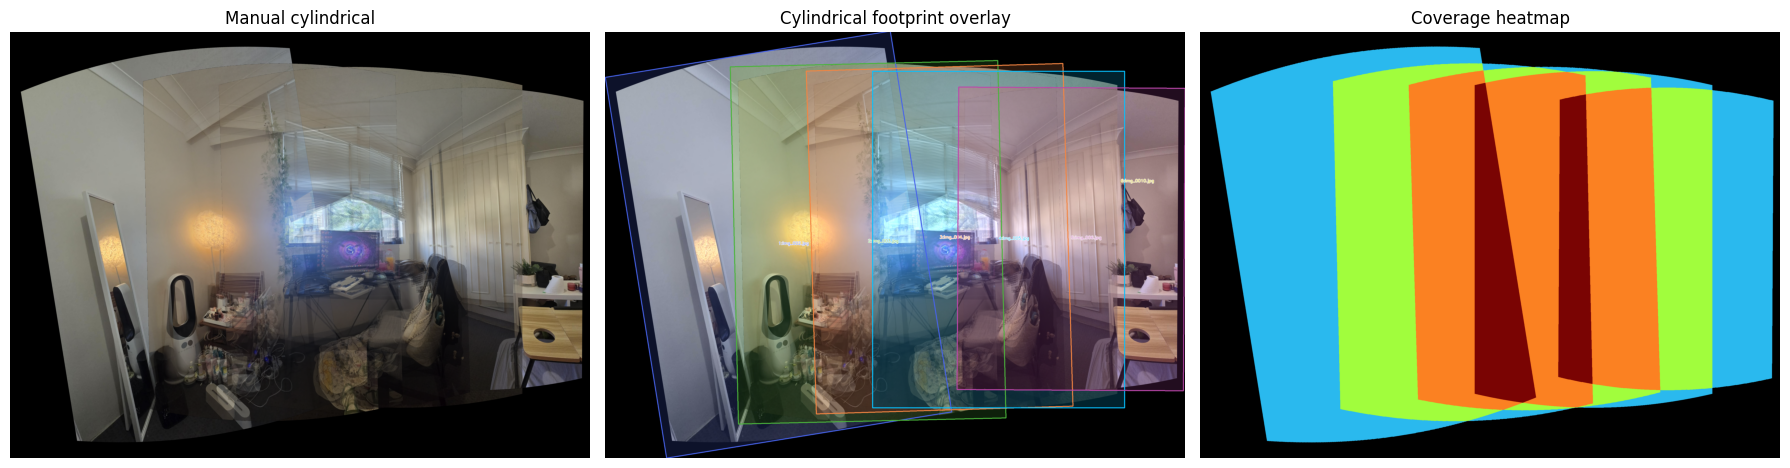

In [40]:
cylindrical_preview_result = manual_cylindrical_preview(
    scene_id=SCENE_ID,
    max_long_edge=CYL_PREVIEW_MAX_LONG_EDGE,
    focal_scale=CYL_PREVIEW_FOCAL_SCALE,
    focal_px_override=CYL_PREVIEW_FOCAL_PX_OVERRIDE,
    anchor_1based=CYL_PREVIEW_ANCHOR,
    save_outputs=CYL_PREVIEW_SAVE_OUTPUTS,
)


## Notes

- Full-canvas preview is best for debugging what the raw homography chain is trying to do.
- Cylindrical preview is usually the better choice for wide around-you sweeps.
- Both previews may keep unstable regions that OpenCV Stitcher would prune away.